In [14]:
from project_paths import paths
import polars as pl
import json

experiment_dir = paths.experiments / "oof_grid"

results_file = experiment_dir / "results.jsonl"

with open(results_file) as f:
    lines = [line for line in f.readlines()]
    results = json.loads(lines[-1])

folds = pl.read_parquet(experiment_dir/"folds.parquet")

oof_predictions = pl.read_parquet(experiment_dir/"oof_predictions.parquet")




In [15]:
folds

asset_id,block_id,fold_id
i64,i16,i8
100006,20,3
100010,20,3
100015,14,3
100016,14,3
100017,14,3
…,…,…
99960,44,9
99963,36,1
99966,31,6


In [16]:
oof_predictions

asset_id,fold_id,feature_set,model,y_true,proba_1,proba_2,proba_3,proba_4,proba_5,y_pred_argmax
i64,i8,enum,enum,i8,f64,f64,f64,f64,f64,i8
100006,3,"""base""","""hgb_default""",3,0.00011,0.083353,0.891178,0.02041,0.004949,3
100010,3,"""base""","""hgb_default""",3,0.000092,0.070052,0.902354,0.025315,0.002188,3
100015,3,"""base""","""hgb_default""",4,0.000425,0.555664,0.422533,0.019729,0.001649,2
100016,3,"""base""","""hgb_default""",3,0.000806,0.476361,0.446707,0.073855,0.00227,2
100017,3,"""base""","""hgb_default""",3,0.000696,0.501019,0.454441,0.041178,0.002667,2
…,…,…,…,…,…,…,…,…,…,…
99960,9,"""base""","""dummy_stratified""",3,0.0,1.0,0.0,0.0,0.0,2
99963,1,"""base""","""dummy_stratified""",3,0.0,1.0,0.0,0.0,0.0,2
99966,6,"""base""","""dummy_stratified""",3,0.0,0.0,1.0,0.0,0.0,3


In [17]:
from pprint import pprint
# pprint(results)

results

{'run_id': '73134c6c-f8f9-44ba-b677-f6b267b30df3',
 'run_at': '2026-07-28 11:11:08',
 'name': 'oof_grid',
 'smoke': False,
 'seed': 123,
 'n_blocks': 50,
 'n_splits': 10,
 'splitter_class': 'StratifiedGroupKFold',
 'n_assets': 23304,
 'grid': [{'cell_id': 'hgb_default__base',
   'model': 'hgb_default',
   'feature_set': 'base',
   'params': {'categorical_features': [0, 1, 2, 3],
    'learning_rate': 0.05,
    'max_iter': 400,
    'early_stopping': True,
    'random_state': 123,
    'class_weight': None,
    'scoring': 'loss'},
   'wants_shap': True},
  {'cell_id': 'hgb_default__base_exp',
   'model': 'hgb_default',
   'feature_set': 'base_exp',
   'params': {'categorical_features': [0, 1, 2, 3],
    'learning_rate': 0.05,
    'max_iter': 400,
    'early_stopping': True,
    'random_state': 123,
    'class_weight': None,
    'scoring': 'loss'},
   'wants_shap': True},
  {'cell_id': 'hgb_qwk_es__base',
   'model': 'hgb_qwk_es',
   'feature_set': 'base',
   'params': {'categorical_feature

In [18]:
from experiments.oof_grid.reporting import load_oof 

oof = oof_predictions.with_columns(
        (pl.col("model").cast(pl.String) + "__" + pl.col("feature_set").cast(pl.String)).alias(
            "cell_id"
        ),
        (pl.col("proba_4") + pl.col("proba_5")).alias("score_ge4"),
        (pl.col("y_true") >= 4).cast(pl.Int8).alias("y_ge4"),
    )

oof

asset_id,fold_id,feature_set,model,y_true,proba_1,proba_2,proba_3,proba_4,proba_5,y_pred_argmax,cell_id,score_ge4,y_ge4
i64,i8,enum,enum,i8,f64,f64,f64,f64,f64,i8,str,f64,i8
100006,3,"""base""","""hgb_default""",3,0.00011,0.083353,0.891178,0.02041,0.004949,3,"""hgb_default__base""",0.025359,0
100010,3,"""base""","""hgb_default""",3,0.000092,0.070052,0.902354,0.025315,0.002188,3,"""hgb_default__base""",0.027502,0
100015,3,"""base""","""hgb_default""",4,0.000425,0.555664,0.422533,0.019729,0.001649,2,"""hgb_default__base""",0.021378,1
100016,3,"""base""","""hgb_default""",3,0.000806,0.476361,0.446707,0.073855,0.00227,2,"""hgb_default__base""",0.076125,0
100017,3,"""base""","""hgb_default""",3,0.000696,0.501019,0.454441,0.041178,0.002667,2,"""hgb_default__base""",0.043844,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…
99960,9,"""base""","""dummy_stratified""",3,0.0,1.0,0.0,0.0,0.0,2,"""dummy_stratified__base""",0.0,0
99963,1,"""base""","""dummy_stratified""",3,0.0,1.0,0.0,0.0,0.0,2,"""dummy_stratified__base""",0.0,0
99966,6,"""base""","""dummy_stratified""",3,0.0,0.0,1.0,0.0,0.0,3,"""dummy_stratified__base""",0.0,0


In [19]:
import numpy as np
from sklearn.metrics import average_precision_score, cohen_kappa_score, mean_absolute_error
from src.cross_validate import GRADES


def fold_metrics(
        y_true: np.ndarray, 
        y_pred: np.ndarray, 
        score_ge4: np.ndarray,
    ) -> dict:

    y_ge4 = (y_true >= 4).astype(np.int64)

    qwk = float(cohen_kappa_score(y_true, y_pred, labels=list(GRADES), weights="quadratic"))

    pr_auc = (
        float(average_precision_score(y_ge4, score_ge4)) if y_ge4.sum() > 0 else float("nan")
    )

    mae = float(mean_absolute_error(y_true, y_pred))
    
    return {
        "n": int(len(y_true)),
        "n_pos_ge4": int(y_ge4.sum()),
        "qwk": qwk,
        "pr_auc_ge4": pr_auc,
        "mae": mae,
    }

In [20]:
rows = []

for (cell_id, model, feature_set, fold_id), group in oof.group_by(
    ["cell_id", "model", "feature_set", "fold_id"], maintain_order=True
):
    metrics = fold_metrics(
        y_true=group["y_true"].to_numpy(), 
        y_pred=group["y_pred_argmax"].to_numpy(), 
        score_ge4=group["score_ge4"].to_numpy(),
    )

    rows.append(
        {"cell_id": cell_id, "model": model, "feature_set": feature_set, "fold_id": fold_id, **metrics}
    )

out = pl.DataFrame(rows).sort("cell_id", "fold_id")

out

cell_id,model,feature_set,fold_id,n,n_pos_ge4,qwk,pr_auc_ge4,mae
str,str,str,i64,i64,i64,f64,f64,f64
"""dummy_median__base""","""dummy_median""","""base""",0,2174,263,0.0,0.120975,0.436063
"""dummy_median__base""","""dummy_median""","""base""",1,2201,188,0.0,0.085416,0.453885
"""dummy_median__base""","""dummy_median""","""base""",2,2486,215,0.0,0.086484,0.35358
"""dummy_median__base""","""dummy_median""","""base""",3,2601,216,0.0,0.083045,0.385621
"""dummy_median__base""","""dummy_median""","""base""",4,2294,182,0.0,0.079337,0.417175
…,…,…,…,…,…,…,…,…
"""hgb_qwk_es__base_exp""","""hgb_qwk_es""","""base_exp""",5,2157,232,0.231623,0.204971,0.465925
"""hgb_qwk_es__base_exp""","""hgb_qwk_es""","""base_exp""",6,2323,286,0.247719,0.187803,0.532071
"""hgb_qwk_es__base_exp""","""hgb_qwk_es""","""base_exp""",7,2351,230,0.203774,0.18093,0.389621


In [21]:
with pl.Config(tbl_rows=-1, tbl_cols=-1, tbl_width_chars=220):
    print(out)

shape: (80, 9)
┌────────────────────────┬──────────────────┬─────────────┬─────────┬──────┬───────────┬───────────┬────────────┬──────────┐
│ cell_id                ┆ model            ┆ feature_set ┆ fold_id ┆ n    ┆ n_pos_ge4 ┆ qwk       ┆ pr_auc_ge4 ┆ mae      │
│ ---                    ┆ ---              ┆ ---         ┆ ---     ┆ ---  ┆ ---       ┆ ---       ┆ ---        ┆ ---      │
│ str                    ┆ str              ┆ str         ┆ i64     ┆ i64  ┆ i64       ┆ f64       ┆ f64        ┆ f64      │
╞════════════════════════╪══════════════════╪═════════════╪═════════╪══════╪═══════════╪═══════════╪════════════╪══════════╡
│ dummy_median__base     ┆ dummy_median     ┆ base        ┆ 0       ┆ 2174 ┆ 263       ┆ 0.0       ┆ 0.120975   ┆ 0.436063 │
│ dummy_median__base     ┆ dummy_median     ┆ base        ┆ 1       ┆ 2201 ┆ 188       ┆ 0.0       ┆ 0.085416   ┆ 0.453885 │
│ dummy_median__base     ┆ dummy_median     ┆ base        ┆ 2       ┆ 2486 ┆ 215       ┆ 0.0       ┆ 0.086484 

In [22]:
id_cols = ["cell_id", "model", "feature_set"]
metric_cols = ["qwk", "pr_auc_ge4", "mae"]

long = out.unpivot(
    index=[*id_cols, "fold_id"], 
    on=metric_cols, 
    variable_name="metric", 
    value_name="value",
)

summary = (
    long.group_by([*id_cols, "metric"], maintain_order=True)
    .agg(
        pl.col("value").drop_nulls().mean().alias("mean"),
        pl.col("value").drop_nulls().std(ddof=0).alias("std"),
        pl.col("value").drop_nulls().len().cast(pl.Int32).alias("n_folds"),
    )
    .sort("cell_id", "metric")
)

summary

cell_id,model,feature_set,metric,mean,std,n_folds
str,str,str,str,f64,f64,i32
"""dummy_median__base""","""dummy_median""","""base""","""mae""",0.421228,0.044603,10
"""dummy_median__base""","""dummy_median""","""base""","""pr_auc_ge4""",0.096583,0.014864,10
"""dummy_median__base""","""dummy_median""","""base""","""qwk""",0.0,0.0,10
"""dummy_stratified__base""","""dummy_stratified""","""base""","""mae""",0.641249,0.018521,10
"""dummy_stratified__base""","""dummy_stratified""","""base""","""pr_auc_ge4""",0.097513,0.015964,10
…,…,…,…,…,…,…
"""hgb_qwk_es__base""","""hgb_qwk_es""","""base""","""pr_auc_ge4""",0.175817,0.031153,10
"""hgb_qwk_es__base""","""hgb_qwk_es""","""base""","""qwk""",0.275953,0.046228,10
"""hgb_qwk_es__base_exp""","""hgb_qwk_es""","""base_exp""","""mae""",0.400144,0.058158,10


In [23]:
with pl.Config(tbl_rows=-1, tbl_cols=-1, tbl_width_chars=220):
    print(summary)

shape: (24, 7)
┌────────────────────────┬──────────────────┬─────────────┬────────────┬───────────┬──────────┬─────────┐
│ cell_id                ┆ model            ┆ feature_set ┆ metric     ┆ mean      ┆ std      ┆ n_folds │
│ ---                    ┆ ---              ┆ ---         ┆ ---        ┆ ---       ┆ ---      ┆ ---     │
│ str                    ┆ str              ┆ str         ┆ str        ┆ f64       ┆ f64      ┆ i32     │
╞════════════════════════╪══════════════════╪═════════════╪════════════╪═══════════╪══════════╪═════════╡
│ dummy_median__base     ┆ dummy_median     ┆ base        ┆ mae        ┆ 0.421228  ┆ 0.044603 ┆ 10      │
│ dummy_median__base     ┆ dummy_median     ┆ base        ┆ pr_auc_ge4 ┆ 0.096583  ┆ 0.014864 ┆ 10      │
│ dummy_median__base     ┆ dummy_median     ┆ base        ┆ qwk        ┆ 0.0       ┆ 0.0      ┆ 10      │
│ dummy_stratified__base ┆ dummy_stratified ┆ base        ┆ mae        ┆ 0.641249  ┆ 0.018521 ┆ 10      │
│ dummy_stratified__base ┆ dumm

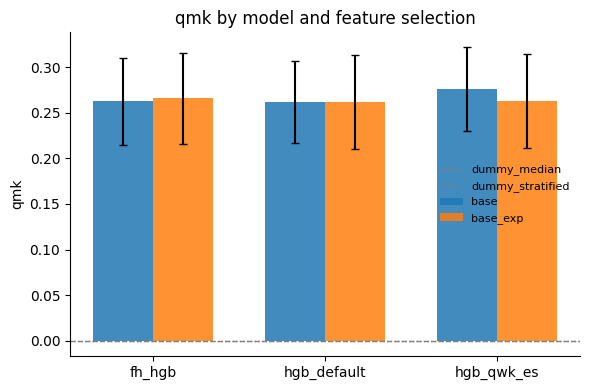

In [24]:
import matplotlib.pyplot as plt

models = ["fh_hgb", "hgb_default", "hgb_qwk_es"]
feature_sets = ["base", "base_exp"]
dummy_models = ["dummy_median", "dummy_stratified"]

MODEL_LABELS = {
    "fh_hgb": "Frank\u2013Hall (HGB)",
    "hgb_default": "HGB (default)",
    "hgb_qwk_es": "HGB (QWK early-stop)",
}

def get_row(
        summary: pl.DataFrame, 
        model: str, 
        feature_set: str, 
        metric: str,
    ) -> tuple[float, float]:

    row = summary.filter(
        (pl.col("model") == model)
        & (pl.col("feature_set") == feature_set)
        & (pl.col("metric") == metric)
    )
    if row.height == 0:
        raise ValueError(f"no row for {model=}, {feature_set=}, {metric=}")
    
    return row["mean"][0], row["std"][0]



fig, ax = plt.subplots(figsize=(6, 4))

x = np.arange(3)
width = 0.35

for i, feats in enumerate(feature_sets):
    means, stds = zip(*[get_row(summary, model, feats, "qwk") for model in models])
    offset = (i - 0.5) * width
    ax.bar(x + offset, means, width, yerr=stds, capsize=3, label=feats, alpha=0.85)

for dummy, linestyle in zip(dummy_models, ["--", ":"]):
    val, _ = get_row(summary, dummy, "base", "qwk")
    ax.axhline(val, color="grey", linestyle=linestyle, linewidth=1, label=dummy)

ax.set_xticks(x)
ax.set_xticklabels([model for model in models])
ax.set_ylabel("qmk")
ax.set_title("qmk by model and feature selection")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(fontsize=8, frameon=False)
fig.tight_layout()

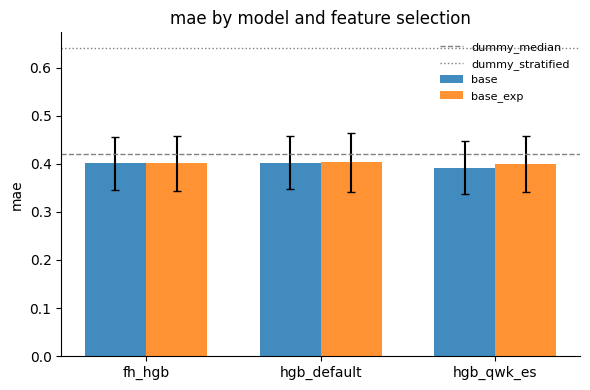

In [25]:
import matplotlib.pyplot as plt

models = ["fh_hgb", "hgb_default", "hgb_qwk_es"]
feature_sets = ["base", "base_exp"]
dummy_models = ["dummy_median", "dummy_stratified"]

MODEL_LABELS = {
    "fh_hgb": "Frank\u2013Hall (HGB)",
    "hgb_default": "HGB (default)",
    "hgb_qwk_es": "HGB (QWK early-stop)",
}

def get_row(
        summary: pl.DataFrame, 
        model: str, 
        feature_set: str, 
        metric: str,
    ) -> tuple[float, float]:

    row = summary.filter(
        (pl.col("model") == model)
        & (pl.col("feature_set") == feature_set)
        & (pl.col("metric") == metric)
    )
    if row.height == 0:
        raise ValueError(f"no row for {model=}, {feature_set=}, {metric=}")
    
    return row["mean"][0], row["std"][0]



fig, ax = plt.subplots(figsize=(6, 4))

x = np.arange(3)
width = 0.35

for i, feats in enumerate(feature_sets):
    means, stds = zip(*[get_row(summary, model, feats, "mae") for model in models])
    offset = (i - 0.5) * width
    ax.bar(x + offset, means, width, yerr=stds, capsize=3, label=feats, alpha=0.85)

for dummy, ls in zip(dummy_models, ["--", ":"]):
    val, _ = get_row(summary, dummy, "base", "mae")
    ax.axhline(val, color="grey", linestyle=ls, linewidth=1, label=dummy)

ax.set_xticks(x)
ax.set_xticklabels([model for model in models])
ax.set_ylabel("mae")
ax.set_title("mae by model and feature selection")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(fontsize=8, frameon=False)
fig.tight_layout()

In [26]:
import matplotlib.pyplot as plt

models = ["fh_hgb", "hgb_default", "hgb_qwk_es"]
feature_sets = ["base", "base_exp"]
dummy_models = ["dummy_median", "dummy_stratified"]

MODEL_LABELS = {
    "fh_hgb": "Frank\u2013Hall (HGB)",
    "hgb_default": "HGB (default)",
    "hgb_qwk_es": "HGB (QWK early-stop)",
}

def get_row(
        summary: pl.DataFrame, 
        model: str, 
        feature_set: str, 
        metric: str,
    ) -> tuple[float, float]:

    row = summary.filter(
        (pl.col("model") == model)
        & (pl.col("feature_set") == feature_set)
        & (pl.col("metric") == metric)
    )
    if row.height == 0:
        raise ValueError(f"no row for {model=}, {feature_set=}, {metric=}")
    
    return row["mean"][0], row["std"][0]


def plot_summary(metric):


    fig, ax = plt.subplots(figsize=(6, 4))

    x = np.arange(3)
    width = 0.35

    for i, feats in enumerate(feature_sets):
        means, stds = zip(*[get_row(summary, model, feats, metric) for model in models])
        offset = (i - 0.5) * width
        ax.bar(x + offset, means, width, yerr=stds, capsize=3, label=feats, alpha=0.85)

    for dummy, ls in zip(dummy_models, ["--", ":"]):
        val, _ = get_row(summary, dummy, "base", metric)
        ax.axhline(val, color="grey", linestyle=ls, linewidth=1, label=dummy)

    ax.set_xticks(x)
    ax.set_xticklabels([model for model in models])
    ax.set_ylabel(metric)
    ax.set_title(f"{metric} by model and feature selection")
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(fontsize=8, frameon=False)
    fig.tight_layout()

    return fig, ax

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'qwk by model and feature selection'}, ylabel='qwk'>)

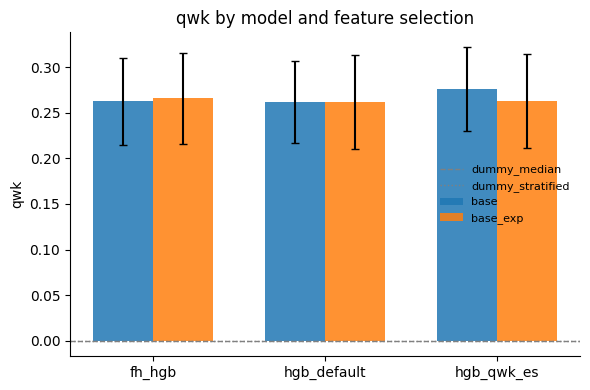

In [27]:
plot_summary("qwk")

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'mae by model and feature selection'}, ylabel='mae'>)

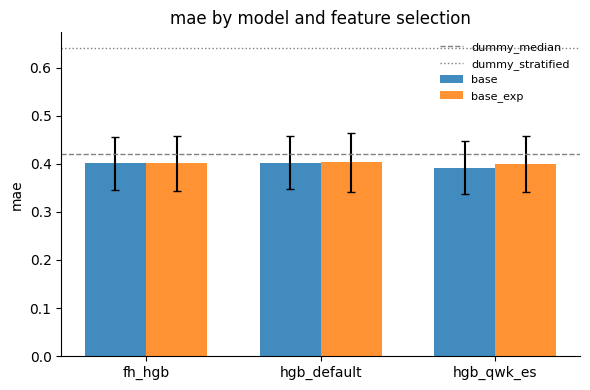

In [28]:
plot_summary("mae")

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'pr_auc_ge4 by model and feature selection'}, ylabel='pr_auc_ge4'>)

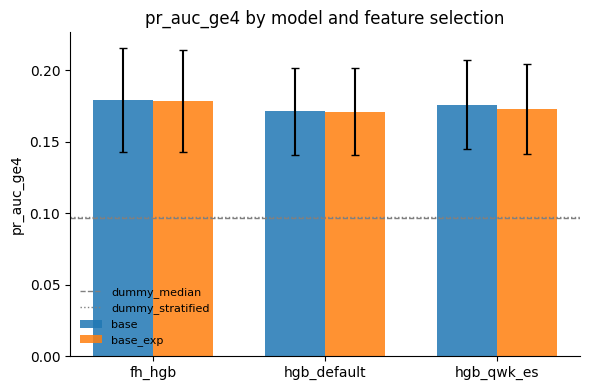

In [29]:
plot_summary("pr_auc_ge4")

really similar performance between the three configs, frank hall promising on increasing pr auc ge4, although qwk scorer is very similar. 
base and base + exposure is so close that not much can be concluded yet. including exposure seems to cause a slight decrease in metrics, but i don't think this is valuable when the models are untuned

In [30]:
GRADE_FRAME = pl.DataFrame({"grade": list(GRADES)}, schema={"grade": pl.Int8})

GRADE_FRAME

grade
i8
1
2
3
4
5


In [31]:
def confusion(oof: pl.DataFrame, by_fold: bool = False) -> pl.DataFrame:
    """5x5 confusion matrix, long form, with zeros filled so all 25 (y_true, y_pred_argmax) cells exist per group
    """
    keys = ["cell_id", "model", "feature_set"] + (["fold_id"] if by_fold else [])

    counted = oof.group_by([*keys, "y_true", "y_pred_argmax"]).agg(pl.len().cast(pl.Int32).alias("n"))

    distinct_cells = oof.select(keys).unique()
    grid = (
        distinct_cells.join(GRADE_FRAME.rename({"grade": "y_true"}), how="cross")
        .join(GRADE_FRAME.rename({"grade": "y_pred_argmax"}), how="cross")
    )

    return (
        grid.join(counted, on=[*keys, "y_true", "y_pred_argmax"], how="left")
        .with_columns(pl.col("n").fill_null(0).cast(pl.Int32))
        .sort([*keys, "y_true", "y_pred_argmax"])
    )

In [32]:
cm = confusion(oof=oof)

cm

cell_id,model,feature_set,y_true,y_pred_argmax,n
str,enum,enum,i8,i8,i32
"""dummy_median__base""","""dummy_median""","""base""",1,1,0
"""dummy_median__base""","""dummy_median""","""base""",1,2,0
"""dummy_median__base""","""dummy_median""","""base""",1,3,447
"""dummy_median__base""","""dummy_median""","""base""",1,4,0
"""dummy_median__base""","""dummy_median""","""base""",1,5,0
…,…,…,…,…,…
"""hgb_qwk_es__base_exp""","""hgb_qwk_es""","""base_exp""",5,1,0
"""hgb_qwk_es__base_exp""","""hgb_qwk_es""","""base_exp""",5,2,15
"""hgb_qwk_es__base_exp""","""hgb_qwk_es""","""base_exp""",5,3,238


In [33]:
import polars.selectors as slt

for cell in cm.get_column("cell_id").unique().to_list():
    confusion_matrix = cm.filter(pl.col("cell_id").eq(cell)).select(slt.exclude("cell_id", "model", "feature_set"))
    index_cols = [c for c in confusion_matrix.columns if c not in ("y_pred_argmax", "n")]
    confusion_matrix = confusion_matrix.pivot(on="y_pred_argmax", index=index_cols, values="n").sort(index_cols)

    with pl.Config():
        print(cell)
        print(confusion_matrix)
        print("\n\n")

fh_hgb__base_exp
shape: (5, 6)
┌────────┬─────┬──────┬───────┬─────┬─────┐
│ y_true ┆ 1   ┆ 2    ┆ 3     ┆ 4   ┆ 5   │
│ ---    ┆ --- ┆ ---  ┆ ---   ┆ --- ┆ --- │
│ i8     ┆ i32 ┆ i32  ┆ i32   ┆ i32 ┆ i32 │
╞════════╪═════╪══════╪═══════╪═════╪═════╡
│ 1      ┆ 55  ┆ 274  ┆ 117   ┆ 1   ┆ 0   │
│ 2      ┆ 70  ┆ 1893 ┆ 4367  ┆ 46  ┆ 0   │
│ 3      ┆ 30  ┆ 1409 ┆ 12598 ┆ 203 ┆ 0   │
│ 4      ┆ 0   ┆ 127  ┆ 1801  ┆ 53  ┆ 1   │
│ 5      ┆ 0   ┆ 17   ┆ 232   ┆ 10  ┆ 0   │
└────────┴─────┴──────┴───────┴─────┴─────┘



fh_hgb__base
shape: (5, 6)
┌────────┬─────┬──────┬───────┬─────┬─────┐
│ y_true ┆ 1   ┆ 2    ┆ 3     ┆ 4   ┆ 5   │
│ ---    ┆ --- ┆ ---  ┆ ---   ┆ --- ┆ --- │
│ i8     ┆ i32 ┆ i32  ┆ i32   ┆ i32 ┆ i32 │
╞════════╪═════╪══════╪═══════╪═════╪═════╡
│ 1      ┆ 54  ┆ 288  ┆ 103   ┆ 2   ┆ 0   │
│ 2      ┆ 65  ┆ 1879 ┆ 4400  ┆ 31  ┆ 1   │
│ 3      ┆ 29  ┆ 1423 ┆ 12607 ┆ 176 ┆ 5   │
│ 4      ┆ 0   ┆ 137  ┆ 1800  ┆ 43  ┆ 2   │
│ 5      ┆ 0   ┆ 18   ┆ 235   ┆ 6   ┆ 0   │
└────────┴─────

In [34]:
import seaborn as sns

ALL_GRADES = [1, 2, 3, 4, 5]

def plot_confusion_matrix(cm_wide: pl.DataFrame, title: str, ax):
    y_true = cm_wide["y_true"].to_list()

    for g in ALL_GRADES:
        col = str(g)
        if col not in cm_wide.columns:
            cm_wide = cm_wide.with_columns(pl.lit(0).alias(col))

    pred_cols = [str(g) for g in ALL_GRADES]
    counts = cm_wide.select(pred_cols).to_numpy().astype(float)

    row_sums = counts.sum(axis=1, keepdims=True)
    display = np.divide(counts, row_sums, out=np.zeros_like(counts), where=row_sums != 0)

    if ax is None:
        _, ax = plt.subplots(figsize=(4.5, 4))

    sns.heatmap(
        display, cmap="viridis", vmin=0, vmax=1, cbar=False,
        xticklabels=pred_cols, yticklabels=y_true, ax=ax,
        linewidths=0.5, linecolor="black",
    )

    for i in range(counts.shape[0]):
        for j in range(counts.shape[1]):
            n = int(counts[i, j])
            val = display[i, j]
            threshold = 0.6
            color = "white" if val < threshold else "black"
            label = f"{val:.0%}\n({n})"
            ax.text(
                j + 0.5, i + 0.5, label, ha="center", va="center", fontsize=8, color=color,)

    ax.set_xlabel("Predicted grade")
    ax.set_ylabel("True grade")
    ax.set_title(title, fontsize=10)
    return ax

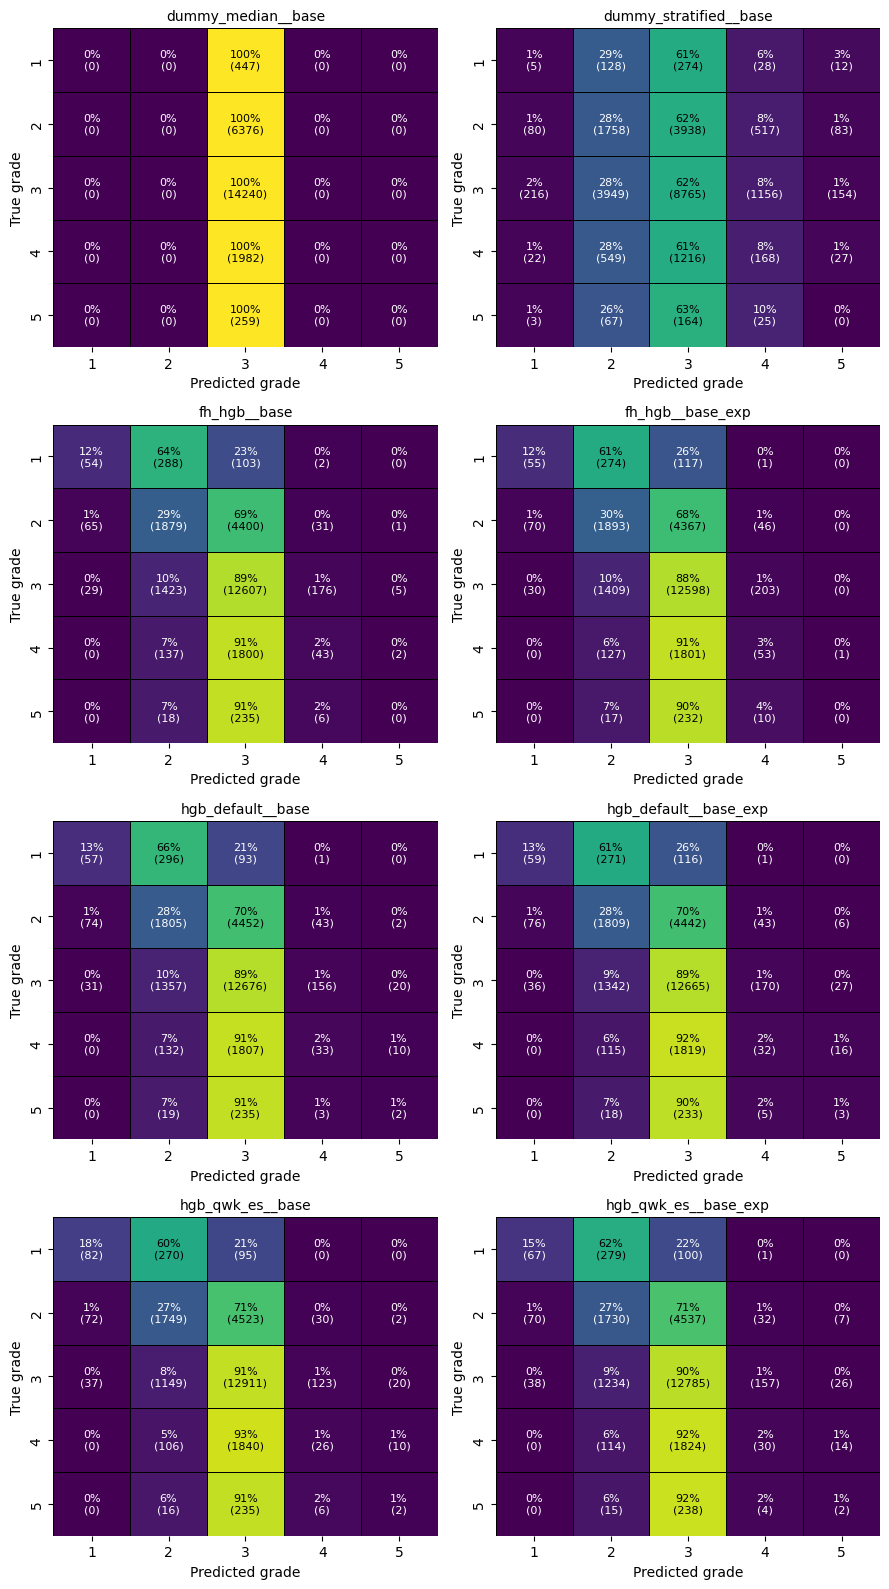

In [35]:
cell_ids = sorted(cm.get_column("cell_id").unique().to_list())
ncols = 2
nrows = -(-len(cell_ids) // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(9, 4 * nrows))
axes = axes.flatten()

for ax, cell in zip(axes, cell_ids):
    confusion_matrix = cm.filter(pl.col("cell_id").eq(cell)).select(
        slt.exclude("cell_id", "model", "feature_set")
    )
    index_cols = [c for c in confusion_matrix.columns if c not in ("y_pred_argmax", "n")]
    confusion_matrix = (
        confusion_matrix.pivot(on="y_pred_argmax", index=index_cols, values="n")
        .sort(index_cols)
    )
    plot_confusion_matrix(confusion_matrix, title=cell, ax=ax)

for ax in axes[len(cell_ids):]:
    ax.axis("off")

fig.tight_layout()
plt.show()

In [36]:
# def per_grade_metrics(
#     oof: pl.DataFrame,
#     by_fold: bool = False,
    
# )

In [37]:
recall_side = (
    cm.group_by("cell_id", "model", "feature_set", "y_true")
    .agg(
        pl.col("n").sum().alias("support"),
        pl.col("n").filter(pl.col("y_pred_argmax") == pl.col("y_true")).sum().alias("tp"),
    )
    .rename({"y_true": "grade"})
)

precision_side = (
    cm.group_by("cell_id", "y_pred_argmax")
    .agg(pl.col("n").sum().alias("predicted"))
    .rename({"y_pred_argmax": "grade"})
)

per_grade = (
    recall_side.join(precision_side, on=["cell_id", "grade"], how="left")
    .with_columns(
        (pl.col("tp") / pl.col("support")).alias("recall"),
        pl.when(pl.col("predicted") > 0)
        .then(pl.col("tp") / pl.col("predicted"))
        .alias("precision"),
    )
    .with_columns(
        pl.when((pl.col("precision") + pl.col("recall")) > 0)
        .then(2 * pl.col("precision") * pl.col("recall") / (pl.col("precision") + pl.col("recall")))
        .alias("f1")
    )
    .sort("cell_id", "grade")
)

per_grade

cell_id,model,feature_set,grade,support,tp,predicted,recall,precision,f1
str,enum,enum,i8,i32,i32,i32,f64,f64,f64
"""dummy_median__base""","""dummy_median""","""base""",1,447,0,0,0.0,null,null
"""dummy_median__base""","""dummy_median""","""base""",2,6376,0,0,0.0,null,null
"""dummy_median__base""","""dummy_median""","""base""",3,14240,14240,23304,1.0,0.611054,0.758577
"""dummy_median__base""","""dummy_median""","""base""",4,1982,0,0,0.0,null,null
"""dummy_median__base""","""dummy_median""","""base""",5,259,0,0,0.0,null,null
…,…,…,…,…,…,…,…,…,…
"""hgb_qwk_es__base_exp""","""hgb_qwk_es""","""base_exp""",1,447,67,175,0.149888,0.382857,0.215434
"""hgb_qwk_es__base_exp""","""hgb_qwk_es""","""base_exp""",2,6376,1730,3372,0.27133,0.513049,0.354945
"""hgb_qwk_es__base_exp""","""hgb_qwk_es""","""base_exp""",3,14240,12785,19484,0.897823,0.656179,0.758214


In [38]:
with pl.Config(tbl_cols=-1, tbl_rows=-1, tbl_width_chars=220):
    print(per_grade)

shape: (40, 10)
┌────────────────────────┬──────────────────┬─────────────┬───────┬─────────┬───────┬───────────┬──────────┬───────────┬──────────┐
│ cell_id                ┆ model            ┆ feature_set ┆ grade ┆ support ┆ tp    ┆ predicted ┆ recall   ┆ precision ┆ f1       │
│ ---                    ┆ ---              ┆ ---         ┆ ---   ┆ ---     ┆ ---   ┆ ---       ┆ ---      ┆ ---       ┆ ---      │
│ str                    ┆ enum             ┆ enum        ┆ i8    ┆ i32     ┆ i32   ┆ i32       ┆ f64      ┆ f64       ┆ f64      │
╞════════════════════════╪══════════════════╪═════════════╪═══════╪═════════╪═══════╪═══════════╪══════════╪═══════════╪══════════╡
│ dummy_median__base     ┆ dummy_median     ┆ base        ┆ 1     ┆ 447     ┆ 0     ┆ 0         ┆ 0.0      ┆ null      ┆ null     │
│ dummy_median__base     ┆ dummy_median     ┆ base        ┆ 2     ┆ 6376    ┆ 0     ┆ 0         ┆ 0.0      ┆ null      ┆ null     │
│ dummy_median__base     ┆ dummy_median     ┆ base        ┆ 

So currently, we can claim that the models are more **precise** than the dummies. But they are all predicting class 4 and 5 far less that those grades exist in the population - shown clearly because the stratified dummy gets this right by definition.

being more precise is a promising result, and the volume of 4 and 5 predictions should be possible to improve by tuning argmax (decrease it). So this is going to be an essential next step.


using qwk for early stopping doesnt change the final qwk score much, but it does seem to make a difference at the grade 1 - grade 2 boundary, with f1 score increasing noticably for the grade 1 row. This is the only grade it seems to affect in this experiment. This is something that non per-grade results didn't show. So qwk vs default for early stopping makes no impact at the macro level but does at the per grade level, for one specific cell.


In [39]:
from scipy.stats import wilcoxon

contrasts = [
    # contrast,     held_fixed,     cell_A,                  cell_B
    ("exposure",  "hgb_default", "hgb_default__base_exp", "hgb_default__base"),
    ("exposure",  "hgb_qwk_es",  "hgb_qwk_es__base_exp",  "hgb_qwk_es__base"),
    ("exposure",  "fh_hgb",      "fh_hgb__base_exp",      "fh_hgb__base"),
    ("ordinal",   "base",        "fh_hgb__base",          "hgb_default__base"),
    ("ordinal",   "base_exp",    "fh_hgb__base_exp",      "hgb_default__base_exp"),
    ("objective", "base",        "hgb_qwk_es__base",      "hgb_default__base"),
    ("objective", "base_exp",    "hgb_qwk_es__base_exp",  "hgb_default__base_exp"),
]
delta_metrics = ["qwk", "pr_auc_ge4"]  # mae is not useful, excluded from the verdict

rows = []
for contrast, held, cell_a, cell_b in contrasts:
    for metric in delta_metrics:
        d = (
            out.filter(pl.col("cell_id") == cell_a).select("fold_id", pl.col(metric).alias("a"))
            .join(
                out.filter(pl.col("cell_id") == cell_b).select("fold_id", pl.col(metric).alias("b")),
                on="fold_id", how="inner",
            )
            .with_columns((pl.col("a") - pl.col("b")).alias("d"))
            .get_column("d")
            .to_numpy()
        )
        try:
            _, p = wilcoxon(d) # exact rank on 10 paired folds
        except ValueError:
            p = float("nan") # all zero deltas, meaningless

        rows.append({
            "contrast": contrast, 
            "held_fixed": held, 
            "metric": metric,
            "mean_delta": float(np.mean(d)),
            "std_delta": float(np.std(d, ddof=0)),
            "n_folds": int(len(d)),
            "n_pos": int((d > 0).sum()), # sign count - under null ~Binom(10, 0.5)
            "wilcoxon_p": float(p), # type: ignore
        })

paired = pl.DataFrame(rows).sort("metric", "contrast", "held_fixed")

with pl.Config(tbl_rows=-1):
    print(paired)

shape: (14, 8)
┌───────────┬─────────────┬────────────┬────────────┬───────────┬─────────┬───────┬────────────┐
│ contrast  ┆ held_fixed  ┆ metric     ┆ mean_delta ┆ std_delta ┆ n_folds ┆ n_pos ┆ wilcoxon_p │
│ ---       ┆ ---         ┆ ---        ┆ ---        ┆ ---       ┆ ---     ┆ ---   ┆ ---        │
│ str       ┆ str         ┆ str        ┆ f64        ┆ f64       ┆ i64     ┆ i64   ┆ f64        │
╞═══════════╪═════════════╪════════════╪════════════╪═══════════╪═════════╪═══════╪════════════╡
│ exposure  ┆ fh_hgb      ┆ pr_auc_ge4 ┆ -0.001095  ┆ 0.008621  ┆ 10      ┆ 5     ┆ 0.845703   │
│ exposure  ┆ hgb_default ┆ pr_auc_ge4 ┆ -0.000078  ┆ 0.007814  ┆ 10      ┆ 4     ┆ 0.845703   │
│ exposure  ┆ hgb_qwk_es  ┆ pr_auc_ge4 ┆ -0.002843  ┆ 0.009379  ┆ 10      ┆ 3     ┆ 0.375      │
│ objective ┆ base        ┆ pr_auc_ge4 ┆ 0.004629   ┆ 0.006236  ┆ 10      ┆ 7     ┆ 0.064453   │
│ objective ┆ base_exp    ┆ pr_auc_ge4 ┆ 0.001865   ┆ 0.006408  ┆ 10      ┆ 7     ┆ 0.322266   │
│ ordinal   ┆ b

i think the biggest takeaway here is that nothing is making a huge impace - no changes in the first decimal point

In [40]:
# sweep over threshold values

from sklearn.metrics import precision_recall_curve

model_cells = sorted(c for c in oof.get_column("cell_id").unique().to_list() if not c.startswith("dummy"))

curves = {}
sweep_rows = []

for cell in model_cells:
    cell_df = oof.filter(pl.col("cell_id") == cell)
    y = cell_df.get_column("y_ge4").to_numpy()
    score = cell_df.get_column("score_ge4").to_numpy()

    prec, rec, thr = precision_recall_curve(y, score)
    curves[cell] = (prec, rec, thr)

    f1 = np.divide(2 * prec * rec, prec + rec, out=np.zeros_like(prec), where=(prec + rec) > 0)
    best = int(np.argmax(f1[:-1])) # exclude the no threshold value

    # what argmax currently is, predict >=4 iff argmax label in {4,5}
    argmax_position = cell_df.get_column("y_pred_argmax").to_numpy() >= 4
    predicted_positive = int(argmax_position.sum())
    actual_positives = int((y == 1).sum())
    true_positives = int((argmax_position & (y == 1)).sum())

    sweep_rows.append({
        "cell_id": cell,
        "maxf1_thr": float(thr[best]),
        "maxf1_precision": float(prec[best]),
        "maxf1_recall": float(rec[best]),
        "maxf1": float(f1[best]),
        "argmax_precision": true_positives / predicted_positive if predicted_positive else float("nan"),
        "argmax_recall": true_positives / actual_positives if actual_positives else float("nan"),
    })

sweep = pl.DataFrame(sweep_rows).sort("cell_id")
sweep

cell_id,maxf1_thr,maxf1_precision,maxf1_recall,maxf1,argmax_precision,argmax_recall
str,f64,f64,f64,f64,f64,f64
"""fh_hgb__base""",0.143256,0.184887,0.410531,0.254954,0.191729,0.022758
"""fh_hgb__base_exp""",0.114397,0.169811,0.514056,0.255291,0.203822,0.028559
"""hgb_default__base""",0.104307,0.160846,0.536368,0.247478,0.177778,0.021419
"""hgb_default__base_exp""",0.123701,0.168394,0.464079,0.247119,0.184818,0.024989
"""hgb_qwk_es__base""",0.127504,0.172229,0.458278,0.250366,0.200913,0.019634
"""hgb_qwk_es__base_exp""",0.139796,0.177649,0.423472,0.250297,0.18315,0.022311


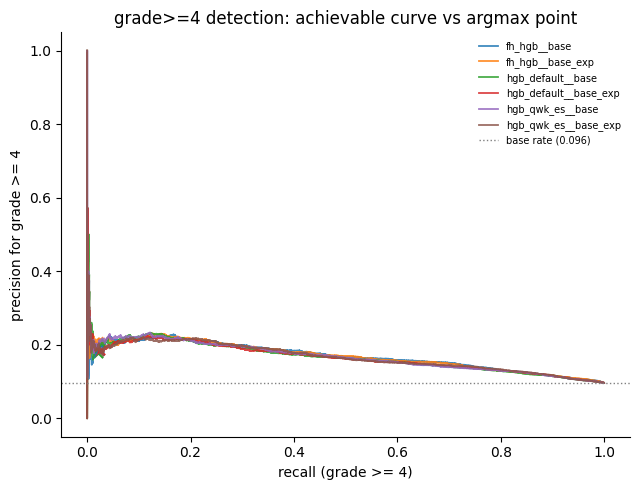

In [41]:
base_rate = float(oof.filter(pl.col("cell_id") == model_cells[0]).get_column("y_ge4").mean())

fig, ax = plt.subplots(figsize=(6.5, 5))
for cell in model_cells:
    prec, rec, _ = curves[cell]
    ax.plot(rec, prec, linewidth=1.3, label=cell, alpha=0.85)
    r = sweep.filter(pl.col("cell_id") == cell)
    ax.scatter(
        r.get_column("argmax_recall").item(), 
        r.get_column("argmax_precision").item(),
        marker="x", 
        s=45, 
        color=ax.lines[-1].get_color()
    )

ax.axhline(base_rate, color="grey", linestyle=":", linewidth=1, label=f"base rate ({base_rate:.3f})")
ax.set_xlabel("recall (grade >= 4)"); ax.set_ylabel("precision for grade >= 4")
ax.set_title("grade>=4 detection: achievable curve vs argmax point")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(fontsize=7, frameon=False)
fig.tight_layout()

In [42]:
shap_files = sorted(experiment_dir.glob("oof_shap*.parquet"))

def load_shap(path):
    cell_id = path.stem.replace("oof_shap__", "")
    df = pl.read_parquet(path)

    shap_cols = [c for c in df.columns if c.startswith("shap__")]

    return (
        df.select("asset_id", "fold_id", *shap_cols)
        .unpivot(index=["asset_id", "fold_id"], on=shap_cols, variable_name="col", value_name="shap")
        .with_columns(pl.col("col").str.replace(r"^shap__", "").alias("fg"))
        .with_columns(
            pl.col("fg").str.replace(r"__grade\d+$", "").alias("feature"), 
            pl.col("fg").str.extract(r"__grade(\d+)$", 1).cast(pl.Int8).alias("grade"),
            pl.lit(cell_id).alias("cell_id"),
        )
        .drop("col", "fg")
    )

shap_long = pl.concat([load_shap(p) for p in shap_files])

shap_importance = (
    shap_long.group_by("cell_id", "feature", "grade")
    .agg(
        pl.col("shap").abs().mean().alias("mean_abs_shap"),   # magnitude / importance
        pl.col("shap").mean().alias("mean_shap"),             # signed direction
    )
    .with_columns(
        pl.col("mean_abs_shap").rank("dense", descending=True).over("cell_id", "grade").alias("rank_in_grade")
    )
    .sort("cell_id", "grade", "rank_in_grade")
)

shap_importance

cell_id,feature,grade,mean_abs_shap,mean_shap,rank_in_grade
str,str,i8,f64,f64,u32
"""hgb_default__base""","""actual_dcl""",1,0.655085,-0.049184,1
"""hgb_default__base""","""age_years""",1,0.593882,0.045077,2
"""hgb_default__base""","""aims__primary_purpose""",1,0.551633,-0.551593,3
"""hgb_default__base""","""design_sop""",1,0.508549,-0.017149,4
"""hgb_default__base""","""asset_length_log1p""",1,0.385047,-0.015674,5
…,…,…,…,…,…
"""hgb_qwk_es__base_exp""","""geosure_landslides__class""",5,0.009522,-0.000561,16
"""hgb_qwk_es__base_exp""","""age_estimated""",5,0.0,0.0,17
"""hgb_qwk_es__base_exp""","""maintainer_is_ea""",5,0.0,0.0,17


In [43]:
EXPOSURE = ["exp__all__2y__cum_area", "exp__all__2y__max_event_area"]

exp_shap = (
    shap_importance
    .filter(pl.col("feature").is_in(EXPOSURE), pl.col("grade") == 4)
    .sort("cell_id", "feature")
)
exp_shap

cell_id,feature,grade,mean_abs_shap,mean_shap,rank_in_grade
str,str,i8,f64,f64,u32
"""hgb_default__base_exp""","""exp__all__2y__cum_area""",4,0.006845,-0.000298,15
"""hgb_default__base_exp""","""exp__all__2y__max_event_area""",4,0.009962,0.001097,14
"""hgb_qwk_es__base_exp""","""exp__all__2y__cum_area""",4,0.006437,-0.000288,15
"""hgb_qwk_es__base_exp""","""exp__all__2y__max_event_area""",4,0.008961,0.000764,14


it looks likely that the best model i create does not include exposure features. 

In [44]:
fh = oof.filter(pl.col("model") == "fh_hgb")

fh


asset_id,fold_id,feature_set,model,y_true,proba_1,proba_2,proba_3,proba_4,proba_5,y_pred_argmax,cell_id,score_ge4,y_ge4
i64,i8,enum,enum,i8,f64,f64,f64,f64,f64,i8,str,f64,i8
100006,3,"""base""","""fh_hgb""",3,0.001778,0.040721,0.918289,0.020814,0.018397,3,"""fh_hgb__base""",0.039212,0
100010,3,"""base""","""fh_hgb""",3,0.001778,0.033663,0.905846,0.027237,0.031477,3,"""fh_hgb__base""",0.058713,0
100015,3,"""base""","""fh_hgb""",4,0.001586,0.551948,0.38472,0.057094,0.004652,2,"""fh_hgb__base""",0.061746,1
100016,3,"""base""","""fh_hgb""",3,0.001237,0.467434,0.47277,0.054466,0.004093,3,"""fh_hgb__base""",0.058559,0
100017,3,"""base""","""fh_hgb""",3,0.001149,0.502129,0.440217,0.05245,0.004055,2,"""fh_hgb__base""",0.056505,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…
99960,9,"""base_exp""","""fh_hgb""",3,0.000882,0.355097,0.523227,0.111712,0.009082,3,"""fh_hgb__base_exp""",0.120795,0
99963,1,"""base_exp""","""fh_hgb""",3,0.00052,0.17804,0.787259,0.027494,0.006687,3,"""fh_hgb__base_exp""",0.034181,0
99966,6,"""base_exp""","""fh_hgb""",3,0.000649,0.147513,0.752554,0.092913,0.006372,3,"""fh_hgb__base_exp""",0.099285,0


In [45]:


# rows should sum to 1 
# some rows should contain exact zeros in proba_2/3/4

check = fh.select(
    (pl.col("proba_1") + pl.col("proba_2") + pl.col("proba_3") + pl.col("proba_4") + pl.col("proba_5")).alias("row_sum")
)

check

row_sum
f64
1.0
1.0
1.0
1.0
1.0
…
1.0
1.0
1.0


In [46]:

print(check.select(pl.col("row_sum").min().alias("min"), pl.col("row_sum").max().alias("max")))   # expect both to be 1.0

shape: (1, 2)
┌─────┬─────┐
│ min ┆ max │
│ --- ┆ --- │
│ f64 ┆ f64 │
╞═════╪═════╡
│ 1.0 ┆ 1.0 │
└─────┴─────┘


In [47]:
EPS = 1e-9

fh = fh.with_columns(
    (pl.col("proba_2") < EPS).alias("clamped_2"),   # inversion at the P(>1)/P(>2) pair
    (pl.col("proba_3") < EPS).alias("clamped_3"),   # at the P(>2)/P(>3) pair
    (pl.col("proba_4") < EPS).alias("clamped_4"),   # at the P(>3)/P(>4) pair  <- touches score_ge4
).with_columns(
    (pl.col("clamped_2") | pl.col("clamped_3") | pl.col("clamped_4")).alias("inverted")
)

fh

asset_id,fold_id,feature_set,model,y_true,proba_1,proba_2,proba_3,proba_4,proba_5,y_pred_argmax,cell_id,score_ge4,y_ge4,clamped_2,clamped_3,clamped_4,inverted
i64,i8,enum,enum,i8,f64,f64,f64,f64,f64,i8,str,f64,i8,bool,bool,bool,bool
100006,3,"""base""","""fh_hgb""",3,0.001778,0.040721,0.918289,0.020814,0.018397,3,"""fh_hgb__base""",0.039212,0,false,false,false,false
100010,3,"""base""","""fh_hgb""",3,0.001778,0.033663,0.905846,0.027237,0.031477,3,"""fh_hgb__base""",0.058713,0,false,false,false,false
100015,3,"""base""","""fh_hgb""",4,0.001586,0.551948,0.38472,0.057094,0.004652,2,"""fh_hgb__base""",0.061746,1,false,false,false,false
100016,3,"""base""","""fh_hgb""",3,0.001237,0.467434,0.47277,0.054466,0.004093,3,"""fh_hgb__base""",0.058559,0,false,false,false,false
100017,3,"""base""","""fh_hgb""",3,0.001149,0.502129,0.440217,0.05245,0.004055,2,"""fh_hgb__base""",0.056505,0,false,false,false,false
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
99960,9,"""base_exp""","""fh_hgb""",3,0.000882,0.355097,0.523227,0.111712,0.009082,3,"""fh_hgb__base_exp""",0.120795,0,false,false,false,false
99963,1,"""base_exp""","""fh_hgb""",3,0.00052,0.17804,0.787259,0.027494,0.006687,3,"""fh_hgb__base_exp""",0.034181,0,false,false,false,false
99966,6,"""base_exp""","""fh_hgb""",3,0.000649,0.147513,0.752554,0.092913,0.006372,3,"""fh_hgb__base_exp""",0.099285,0,false,false,false,false


In [48]:
inversion = (
    fh.group_by("cell_id")
    .agg(
        pl.len().alias("n_assets"),
        pl.col("inverted").sum().alias("n_inverted"),
        pl.col("inverted").mean().alias("inversion_rate"),
        pl.col("clamped_2").mean().alias("rate_clamp_2"),
        pl.col("clamped_3").mean().alias("rate_clamp_3"),
        pl.col("clamped_4").mean().alias("rate_clamp_4"),
    )
    .sort("cell_id")
)

inversion

cell_id,n_assets,n_inverted,inversion_rate,rate_clamp_2,rate_clamp_3,rate_clamp_4
str,u32,u32,f64,f64,f64,f64
"""fh_hgb__base""",23304,388,0.01665,0.001159,0.000086,0.015405
"""fh_hgb__base_exp""",23304,299,0.01283,0.000944,0.0,0.011886


this was to test how often the rows had to be normalised because the probability at one boundary was lower than at a lower grade boundary and would have produced a negative probability. 
the output shows that this happens on only about 1% of rows. This is a good finding - the 0 probability clipping and re normalisation is doing almost nothing. This means the numbers reported in the aggregate stats are trustworthy.

In [51]:
import polars.selectors as cs

from experiments.baseline.baseline import prepare_features

CELL = "hgb_default__base"
shap_wide = pl.read_parquet(experiment_dir / f"oof_shap__{CELL}.parquet")

# feature names from the shap columns, order preserved
features = [
    c.removeprefix("shap__").removesuffix("__grade4")
    for c in shap_wide.columns
    if c.startswith("shap__") and c.endswith("__grade4")
]

# df = the raw unified frame from the experiment

df_feats = prepare_features(pl.read_parquet(paths.processed_data / "unified_aims_eir_bgs.parquet"))

# align feature values to the SHAP row order, selected by name to match feats

X_df = (
    shap_wide.select("asset_id")
    .join(df_feats, on="asset_id", how="left")
    .select(features)
)


X_num = X_df.with_columns(cs.by_dtype(pl.Enum).to_physical()).to_numpy()

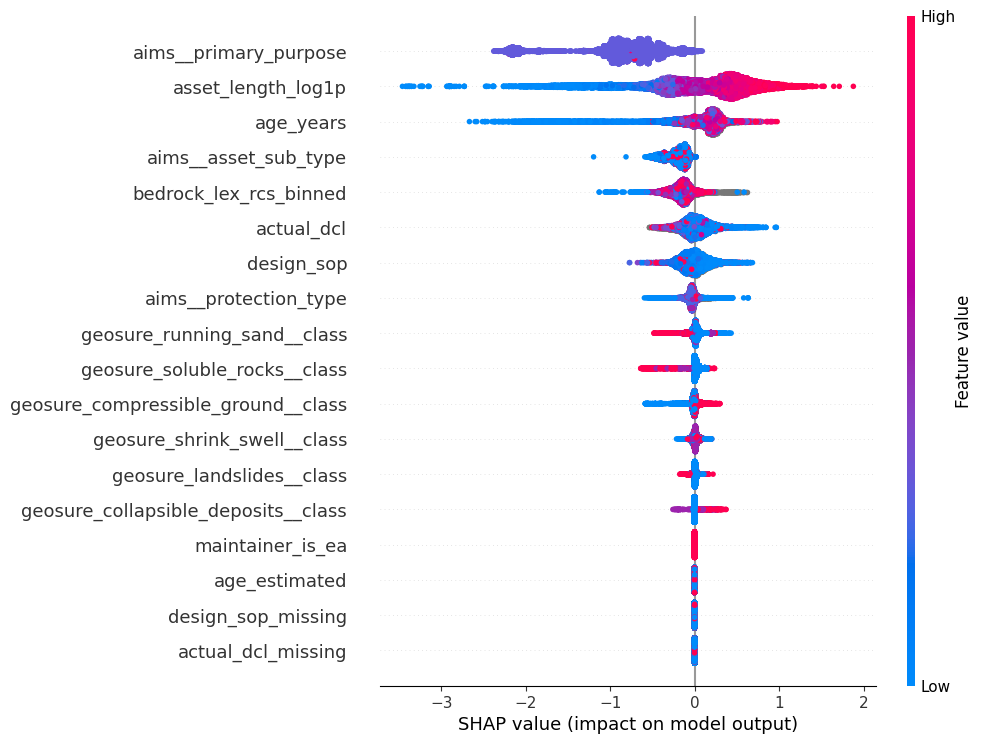

In [52]:
import shap 


def explanation_for_grade(k: int) -> shap.Explanation:
    scols = [f"shap__{f}__grade{k}" for f in features]
    values = shap_wide.select(scols).to_numpy()
    base = float(shap_wide.get_column(f"base_value__grade{k}").head(1).item())
    return shap.Explanation(
        values=values,
        base_values=np.full(values.shape[0], base),
        data=X_num,
        feature_names=features,
    )

expl4 = explanation_for_grade(4) # grade 4 - boundary i have decided is most important to be able to show the model can decern

shap.plots.beeswarm(expl4, max_display=len(features), show=True)

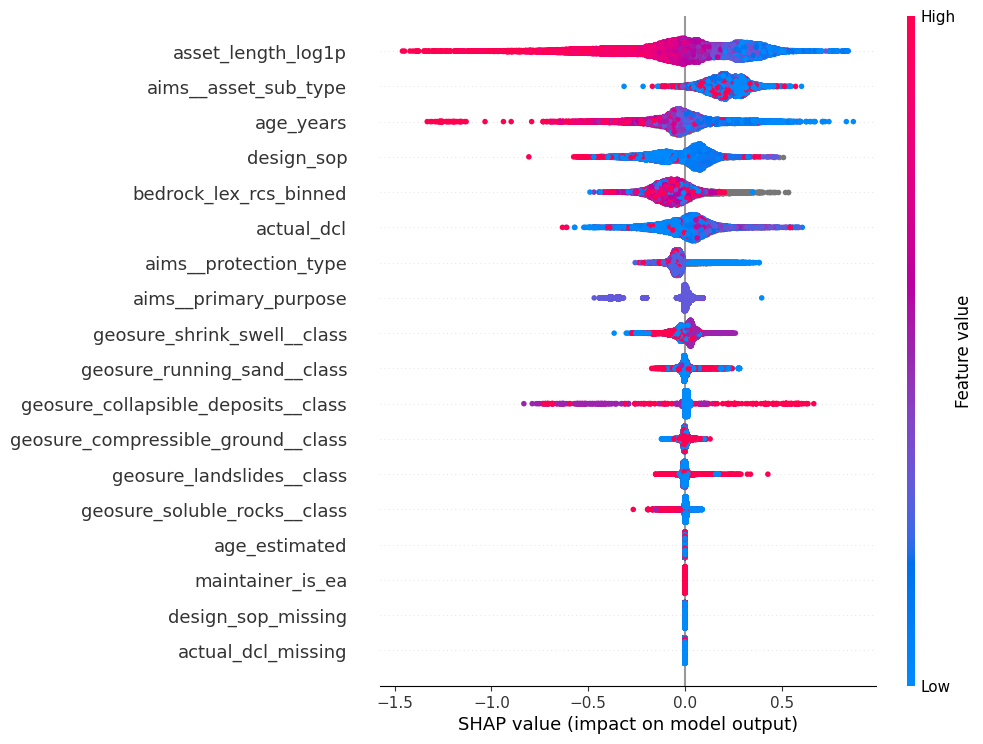

In [53]:
expl2 = explanation_for_grade(2)

shap.plots.beeswarm(expl2, max_display=len(features), show=True)

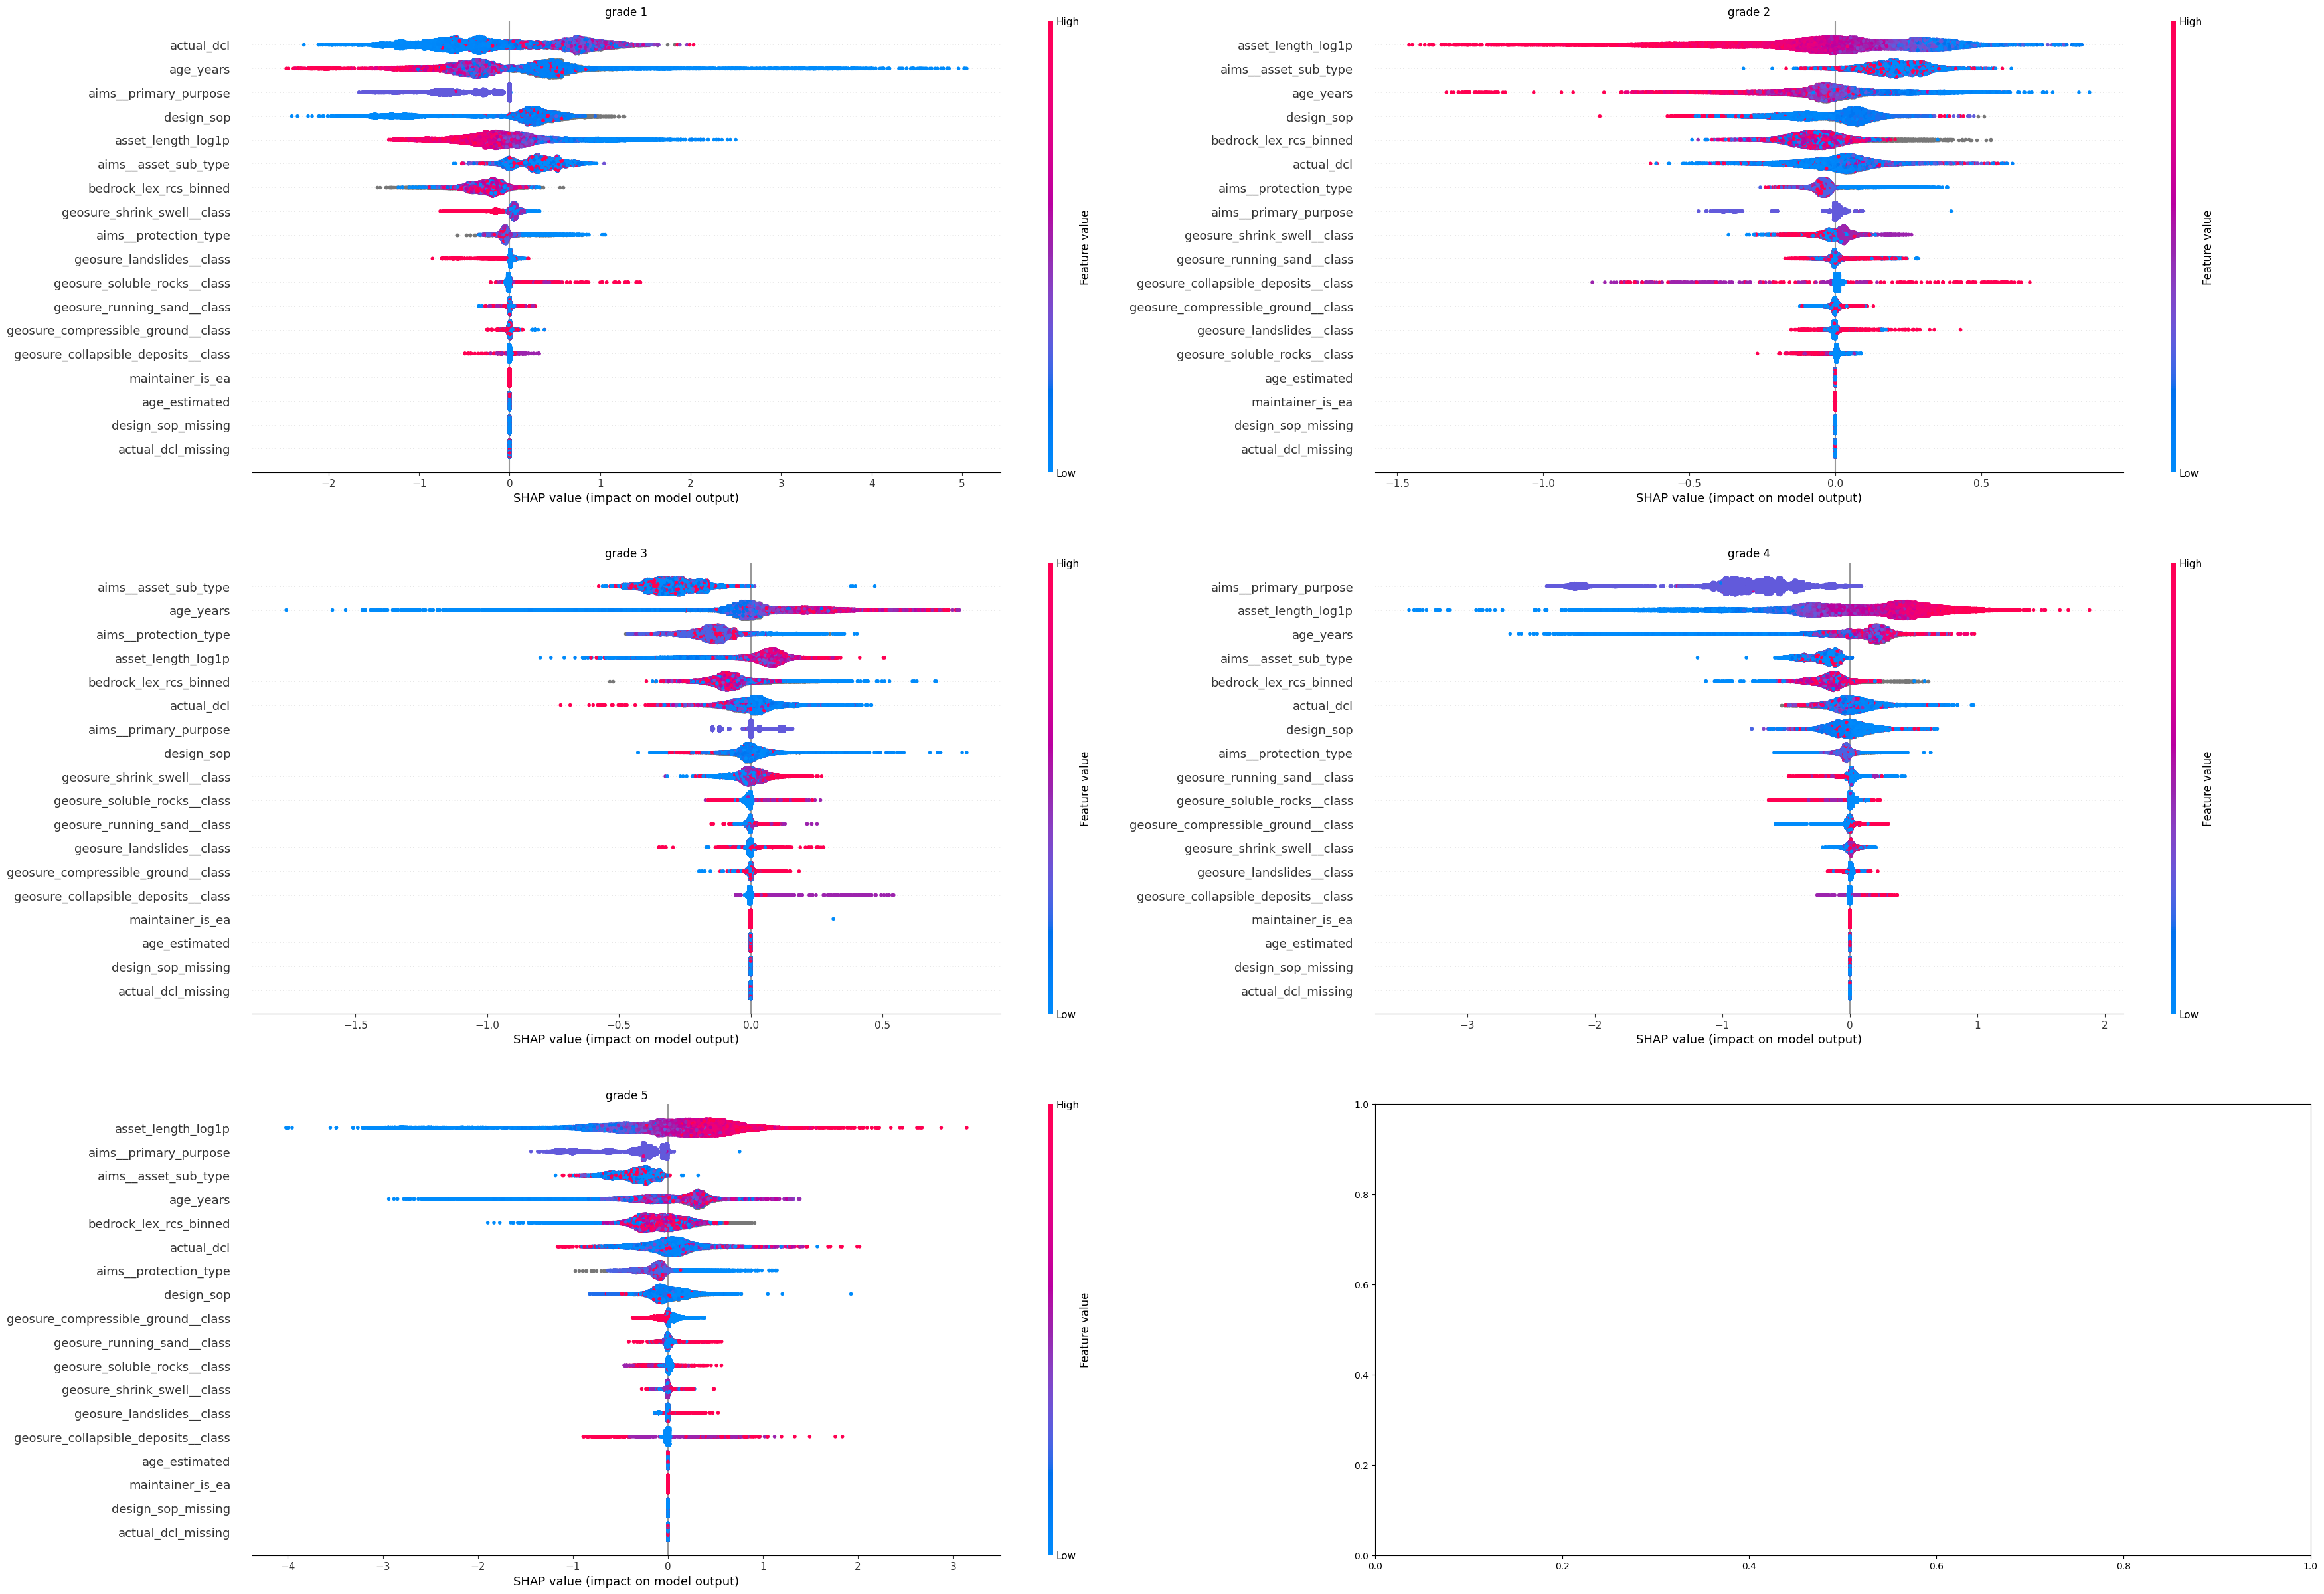

In [72]:
from itertools import chain

fig, axs = plt.subplots(3,2, figsize=(40,30))
axs = [ax for ax in chain(*axs)]

for i in range(5):
    ax = axs[i]
    grade = i+1

    exp = explanation_for_grade(grade)

    p = shap.plots.beeswarm(exp, max_display=len(features), show=False, ax=ax, plot_size=None )
    ax.set_title(f"grade {grade}")


plt.show()


In [78]:
from experiments.oof_grid.runner import EXPOSURE_PARQUET, EXP_COLS, TRUNC_COL 

# code for base features redone for different cell 

CELL = "hgb_default__base_exp"
shap_wide = pl.read_parquet(experiment_dir / f"oof_shap__{CELL}.parquet")

# feature names from the shap columns, order preserved
features = [
    c.removeprefix("shap__").removesuffix("__grade4")
    for c in shap_wide.columns
    if c.startswith("shap__") and c.endswith("__grade4")
]


# code for producing exposure features, borrowed from experiment runner code

exposure = pl.read_parquet(EXPOSURE_PARQUET).select(
        "asset_id", *EXP_COLS
    )
df_full_features = df_feats.join(
    exposure, on="asset_id", how="left", validate="1:1", maintain_order="left"
)
joined = shap_wide.join(df_full_features.select("asset_id", *features), on="asset_id", how="left")

X = joined.select(features).with_columns(cs.by_dtype(pl.Enum).to_physical()).to_numpy()


def explanation_for_grade(k: int) -> shap.Explanation:
    scols = [f"shap__{f}__grade{k}" for f in features]
    values = shap_wide.select(scols).to_numpy()
    base = float(shap_wide.get_column(f"base_value__grade{k}").head(1).item())
    return shap.Explanation(
        values=values,
        base_values=np.full(values.shape[0], base),
        data=X,
        feature_names=features,
    )




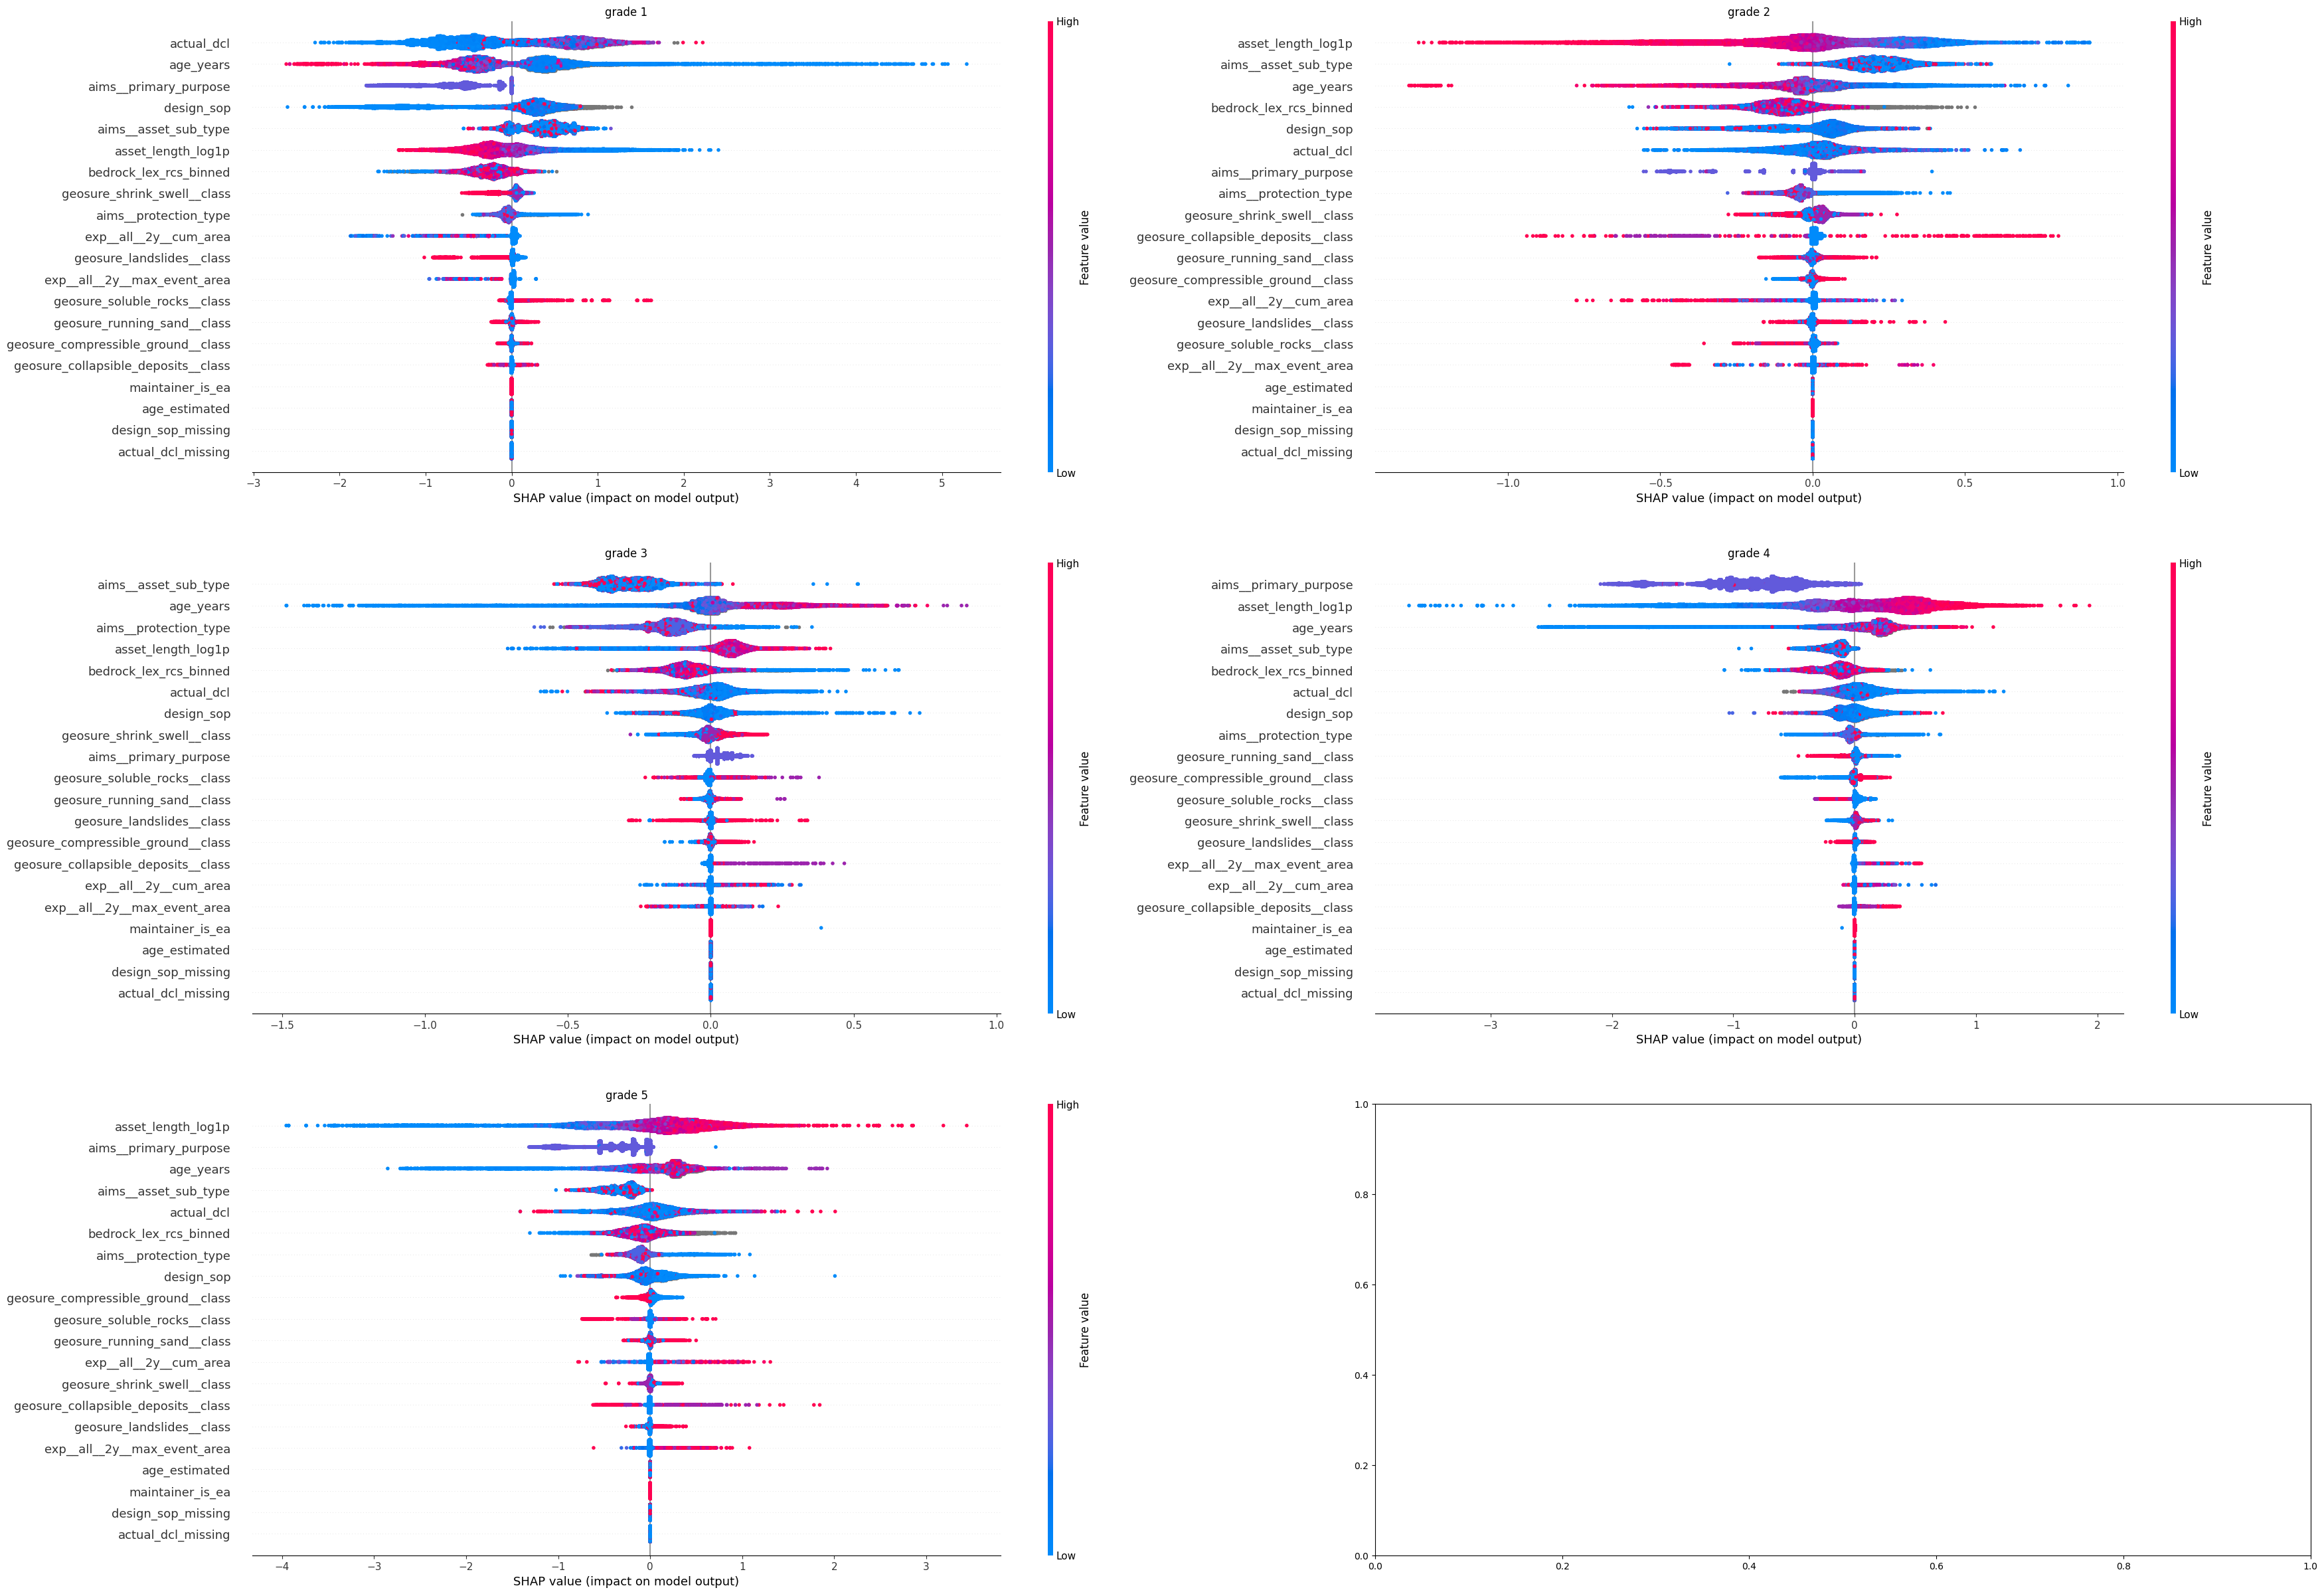

In [79]:
fig, axs = plt.subplots(3,2, figsize=(40,30))
axs = [ax for ax in chain(*axs)]

for i in range(5):
    ax = axs[i]
    grade = i+1

    exp = explanation_for_grade(grade)

    p = shap.plots.beeswarm(exp, max_display=len(features), show=False, ax=ax, plot_size=None )
    ax.set_title(f"grade {grade}")


plt.show()

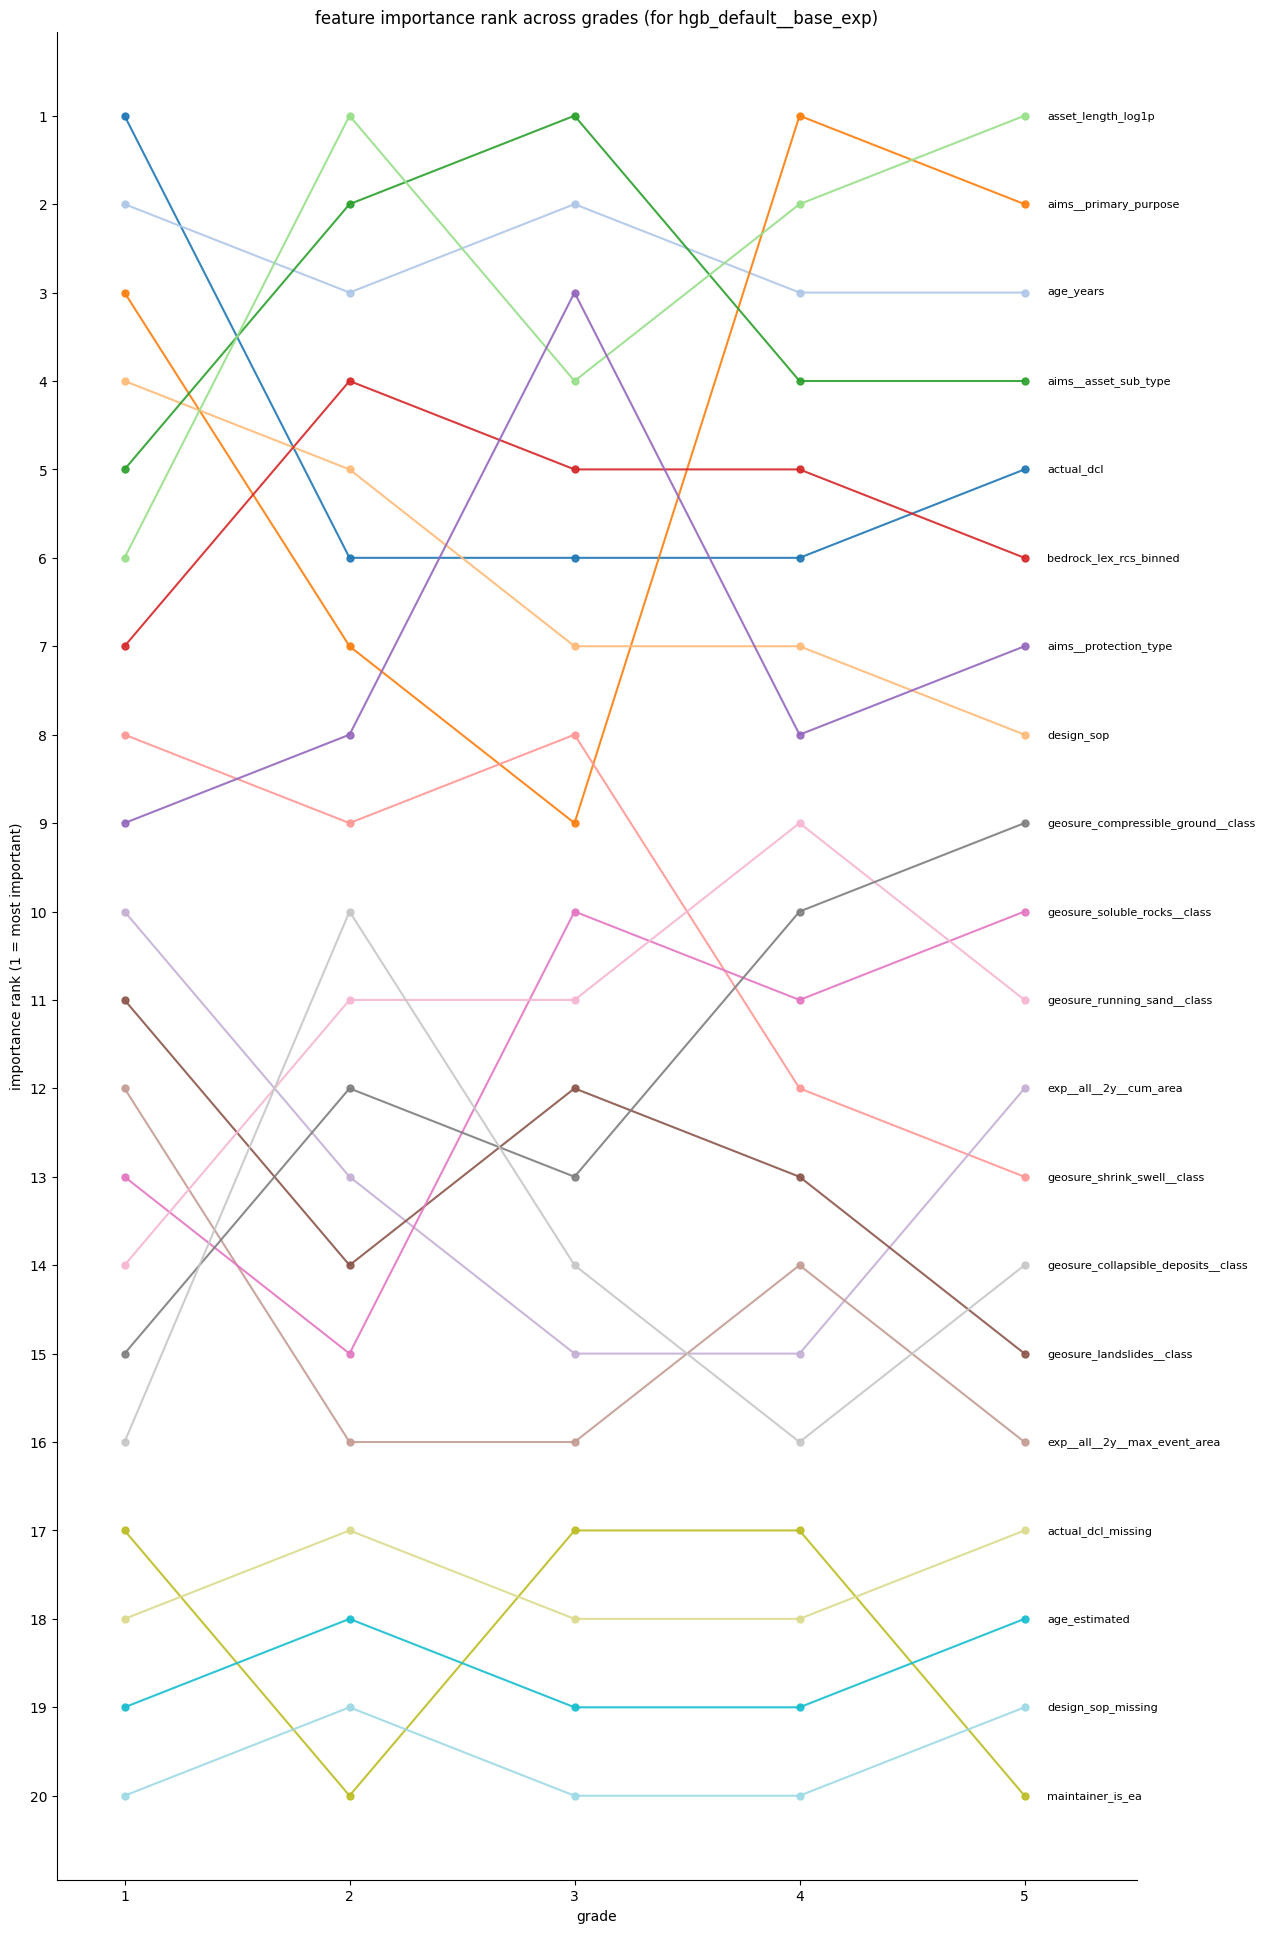

In [93]:
# to show how importance for features changes for different grades
# previously i tried to interpret that from scatter plots of shap values at each grade for each feature
# this was hard to read and impossible to include in a write up
# trying a "bump plot"


importance = (
    shap_importance
    .filter(pl.col("cell_id") == CELL)
    .sort("grade", "mean_abs_shap", "feature", descending=[False, True, False])
    .with_columns(
        pl.col("mean_abs_shap")
        .rank(method="ordinal", descending=True)
        .over("grade")
        .cast(pl.Int32)
        .alias("plot_rank")
    )
)

grades = [1, 2, 3, 4, 5]

# start with order for grade 1 importances

features = importance.filter(pl.col("grade") == 1).sort("plot_rank").get_column("feature").to_list()


fig, ax = plt.subplots(figsize=(24, 24))
fig.subplots_adjust(left=0.25, right=0.70)   # canvas room for the endpoint labels

cmap = plt.get_cmap("tab20")
colours = {f: cmap(i % 20) for i, f in enumerate(features)}

for f in features:
    sub = importance.filter(pl.col("feature") == f).sort("grade")

    xs = sub.get_column("grade").to_list()
    ys = sub.get_column("plot_rank").to_list()

    ax.plot(
        xs, 
        ys, 
        "-o", 
        linewidth=1.5, 
        markersize=5, 
        alpha=0.9,
        c=colours[f]
    )

    # ax.text(
    #     xs[0] - 0.10, 
    #     ys[0], 
    #     f, 
    #     ha="right", 
    #     va="center",
    #     fontsize=8, 
    #     clip_on=False
    # )

    ax.text(
        xs[-1] + 0.10, 
        ys[-1], 
        f, 
        ha="left", 
        va="center",
        fontsize=8, 
        clip_on=False
    )


ax.set_xticks(grades)
ax.set_yticks(range(1, len(features) + 1))
ax.set_xlim(0.7, 5.5)
ax.invert_yaxis() # rank 1 highest, at the top
ax.set_xlabel("grade")
ax.set_ylabel("importance rank (1 = most important)")
ax.set_title(f"feature importance rank across grades (for {CELL})")
ax.spines[["top", "right"]].set_visible(False)

plt.show()



looks like age and the bedrock lex rcs feature are both stable and near the top, whereas other features at the top end like asset type, protection type, subtype, primary purpose move much more significantly. 
this could be because these features are carrying a similar signal that is shared between them, so the relative importances of each is unstable while the total signal is steady (shared signal importance could "add up" to a steady number each time? SHAPs dont actually work like that, but that would be a way to intuit it...). Impossible to prove/disprove that idea here.

bottom end of the graph is pretty steady. Nothing to be inferred from any of the changes in the bottom half because the magnitudes of these features are all low and very similar - no meaningfull difference in being ranked 17th vs 20th.




In [83]:
# with pl.Config(tbl_rows=-1):
#     print(bump)

This experiment included the exposure features, and compared modelling decisions including frank hall decomp, use of quadratic weighted cohen's kappa to optimise early stopping of the histogram gradient boosting model. Along with the baseline hbg and two dummies (predict the median and predict by pulling randomly from the known prior distribution of asset grades), this created a grid producing 8 predictors (2 feature sets X 3 models, plus two dummies). 

The 10 fold spatial cv was kept, and out of fold results were recorded. This means that the confusion matrix of each fold could be inspected, and the actual models in each fold could be used to calculate SHAP score values which could be inspected in this notebook. 

## experiment findings

1. the >= grade 4 boundary shows promise.

By looking at the confusion matrices per grade, and the sweep of argmax, there is definitely an impovement in predicting the grade 4 boundary from the models to the baselines. pr_auc_ge4 = ~0.17 vs floor of 0.097. This is the evidence that the model has learned some skill at decerning the grade 4 and 5 assets from the grade 1 to 3 assets. Very small edge, but present. 
The argmax sweep is necessary to get this advantage. The threshold needs to be set carefully, but there is some promise that the model could one day become a usable screening tool (long way to go).

2. model and data choices 

model architecture has very little impact. frank hall, the base hgb and the early stopping using qwk hbg model all have headline metrics with differences within the natural noise magnitude of each fold. So little meaningful difference. 
The exposure features added basically no information to the model. Three peices of evidence were found across the notebook:
    1. comparing metrics such as pr_auc_ge4 between the models with and without the features shows little difference
    2. ranked 14 to 15 in shap value analysis, below the existing important features in baseline hgb model
    3. magnitude of the shap score is close to 0

one architectural choice which may still carry some interest is the qwk early stopping increased the qwk slightly. Its a very small improvement (+0.014, 10/10 folds) and its not really very interesting (optimised for qwk, improved qwk, not exactly surprising). 

3. bump plots and beeswarms

primary purpose and asset lenght carry the most important signals for predicting the higher grades (4 and 5). primary purpose's importance rank drops sharply when predicting the median score. geology tends to be fairly unimportant.

One theme here is that the most important features are the ones to do with the identity and design of the asset, not the conditions or events its exposed to or something individual about its location/design. In other words, the types of features that could feed into a heuristic when it was constructed. Given this, its interesting that its still beating the actual heuristic (using numbers in nb13, not directly comparing here). 



In the next experiment, I will add in the climate and lidar features, likely drop the exposure features, add a larger hyperparameter training grid, and pay attention to tuning the argmax threshold.